# Student Performance Assignment 

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Importing and Knowing About Data

In [2]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [4]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## Data Cleaning

In [5]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [6]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes':1, 'No':0})

In [7]:
X = df.drop('Performance Index', axis=1)

In [8]:
y = df['Performance Index']

## Using Train Test Split And Linear Regression(For Training)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

LinearRegression()

In [11]:
model.coef_

array([2.85248393, 1.0169882 , 0.60861668, 0.47694148, 0.19183144])

In [12]:
model.intercept_

np.float64(-33.92194621555627)

In [13]:
y_pred_train =  model.predict(X_train)

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
r2_score(y_train, y_pred_train)

0.9886898790682355

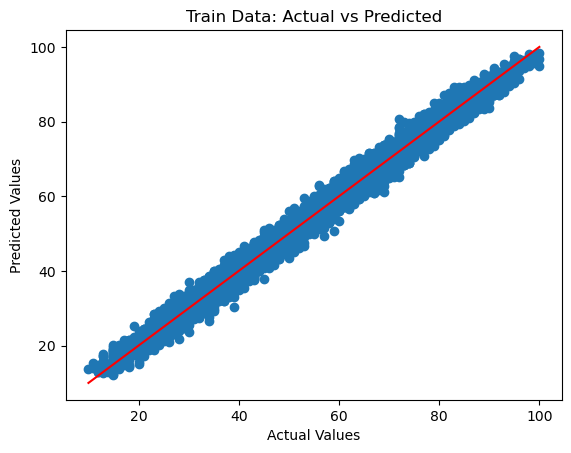

In [16]:
plt.scatter(y_train, y_pred_train)

plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Train Data: Actual vs Predicted")

plt.show()

## Using Train Test Split And Linear Regression(For Testing)

In [17]:
model.fit(X_test, y_test)

LinearRegression()

In [18]:
model.coef_

array([2.85587953, 1.02411464, 0.62226177, 0.49218895, 0.20052196])

In [19]:
model.intercept_

np.float64(-34.65562543930537)

In [20]:
y_pred_train =  model.predict(X_test)

In [21]:
r2_score(y_test, y_pred_train)

0.989046049971872

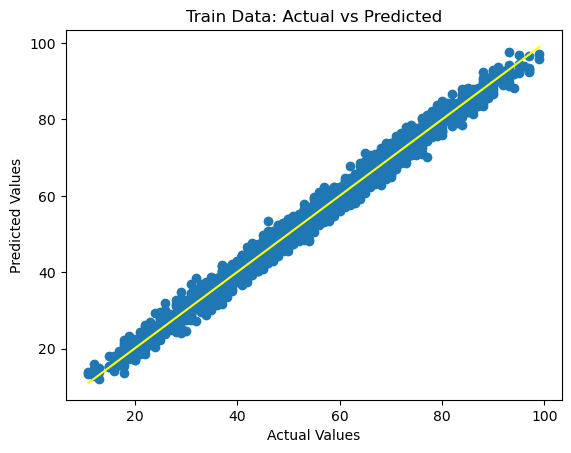

In [22]:
plt.scatter(y_test, y_pred_train)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],color='yellow')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Train Data: Actual vs Predicted")

plt.show()

# Student Performance Dataset – Conclusion

The Linear Regression model was successfully applied to predict student performance based on various academic and lifestyle factors. After performing data preprocessing and training the model, the results showed a strong relationship between input features such as hours studied, previous scores, and practice habits with the performance index. The model achieved a good R² score, indicating that it is capable of explaining a significant portion of the variation in student performance. Overall, this demonstrates that machine learning techniques like Linear Regression can be effectively used to analyze educational data and make reliable predictions.